# Titanic Dataset Exploratory Data Analysis (EDA)

## Data Science with Python Internship - Task 3

This project performs Exploratory Data Analysis (EDA) on the Titanic dataset to identify survival patterns using data cleaning, feature engineering, and visualizations.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [17]:
df = pd.read_csv('titanic.csv')

In [18]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Dataset Overview
Checking dataset shape, columns, data types and missing values.

In [19]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Missing Values:
PassengerId      0
Survived 

## Data Cleaning
- Fill missing Age values with mean.
- Fill missing Embarked values with mode.
- Drop Cabin column because it contains too many missing values.

In [20]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

df['Embarked'] = df['Embarked'].fillna(
    df['Embarked'].mode()[0]
)

df.drop(columns=['Cabin'], inplace=True)

df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


## Feature Engineering: Age Groups
Passengers are divided into different age categories.

In [21]:
bins = [0,12,18,30,50,80]
labels = ['Child','Teen','Young Adult','Adult','Senior']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Adult
4,35.0,Adult


In [22]:
age_survival = df.groupby(
    'AgeGroup',
    observed=False
)['Survived'].mean()

print(age_survival)

AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.331096
Adult          0.423237
Senior         0.343750
Name: Survived, dtype: float64


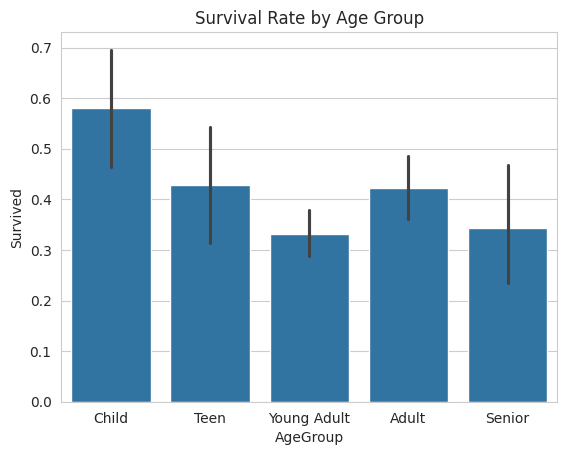

In [23]:
sns.barplot(
    x='AgeGroup',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Age Group")
plt.show()

## Survival Rate by Embarkation Port

In [24]:
embarked_survival = df.groupby(
    'Embarked'
)['Survived'].mean()

print(embarked_survival)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


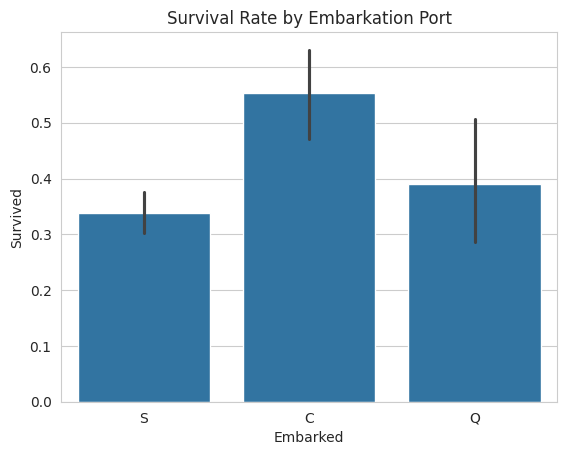

In [25]:
sns.barplot(
    x='Embarked',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Embarkation Port")
plt.show()

## Feature Engineering: Family Size
Family Size = SibSp + Parch

In [26]:
df['FamilySize'] = (
    df['SibSp'] +
    df['Parch']
)

In [27]:
family_survival = df.groupby(
    'FamilySize'
)['Survived'].mean()

print(family_survival)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


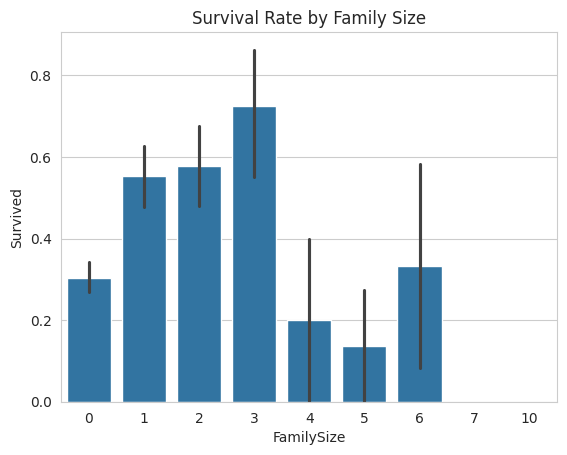

In [28]:
sns.barplot(
    x='FamilySize',
    y='Survived',
    data=df
)

plt.title("Survival Rate by Family Size")
plt.show()

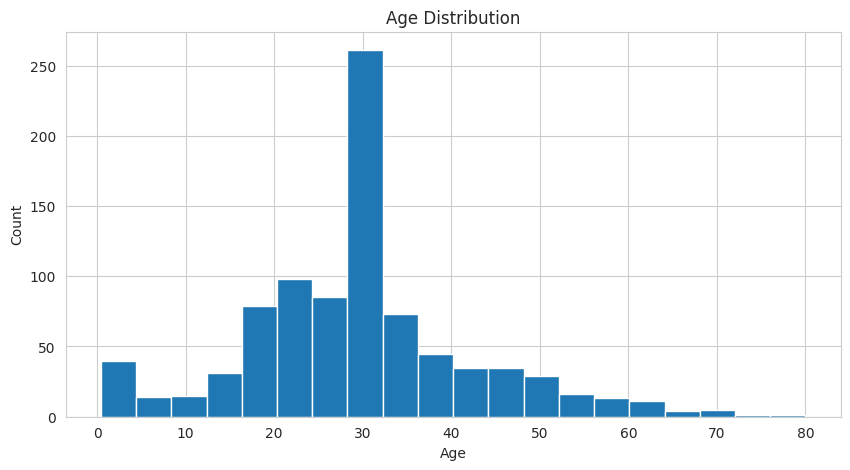

In [29]:
plt.figure(figsize=(10,5))

plt.hist(
    df['Age'],
    bins=20
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

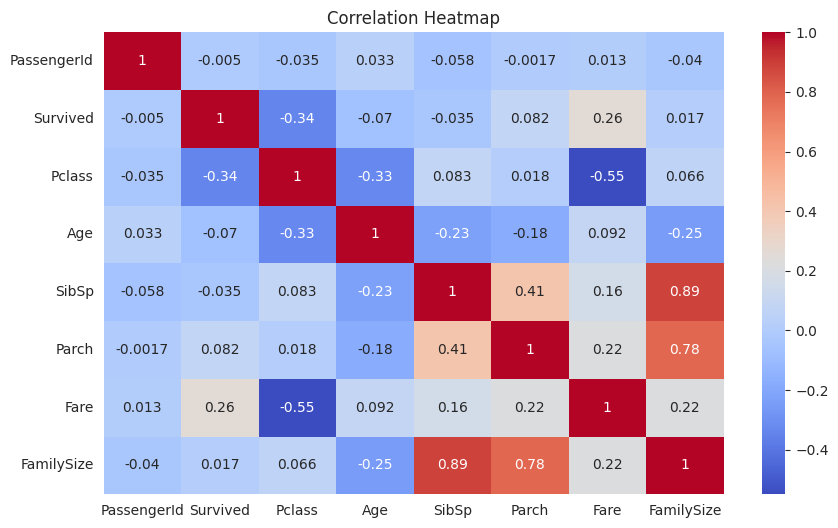

In [30]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# Insights

1. Children had the highest survival rate.
2. Passengers embarking from port C showed better survival rates.
3. Small families had higher survival chances.
4. Elderly passengers had lower survival rates.
5. Females generally survived more than males.

# Conclusion

This project demonstrates data cleaning, feature engineering, exploratory data analysis, and visualization techniques using Python libraries such as Pandas, Matplotlib, and Seaborn.